# Siddak Marwaha
# CMSE 381 HW4

### Q 5.4.3

a)

K-fold cross-validation is a resampling procedure used to evaluate the performance of a model on a limited data set. The steps are:

1. Split the data into k folds. The entire dataset is randomly divided into k equal-sized subsets or folds.

2. Train and evaluate on each fold. For each iteration, one fold is selected as the validation set, and the remaining k-1 folds are combined to form the training set. A model is trained on the training set and its performance is evaluated on the validation set, using a performance metric such as mean squared error (MSE) or accuracy.

3. Repeat the process k times. Each time selecting a different fold as the validation set and training the model on the remaining k-1 folds.

4. Compute the average performance. After completing all k iterations, the performance metric (e.g., MSE or accuracy) from each iteration is averaged to produce the overall estimate of the model’s performance.

b)

The Validation Set Approach:

Advantages of k-fold CV over the validation set method:

1. The validation set approach can lead to high variance in the test error estimates, depending heavily on the specific split of the data. K-fold CV averages the results over k different splits, leading to a more reliable estimate of the model’s performance.

2. In the validation set approach, a portion of the data is held out for validation and not used in training. K-fold CV ensures that every observation is used both for training and validation, maximizing the use of available data.


Disadvantages of k-fold CV:

1. Computational cost: K-fold CV requires fitting the model k times (once for each fold), which is more computationally expensive than a single split used in the validation set approach.


Leave-One-Out Cross-Validation (LOOCV):

Advantages of k-fold CV over LOOCV:

1. LOOCV requires fitting the model n times, whereas k-fold CV only requires fitting the model k times (where k is usually much smaller than n). For large datasets, LOOCV can be computationally expensive, while k-fold CV (especially with k = 5 or 10) is more feasible.
2. The models in LOOCV are trained on almost identical data sets (n-1 observations), which results in highly correlated estimates of the test error and can lead to high variance. In contrast, k-fold CV introduces more variability in the training data, which reduces the correlation between the models and results in lower variance in the error estimates.


Disadvantages of k-fold CV:

1. LOOCV uses almost all the data (n-1 observations) for training, so it gives an almost unbiased estimate of the true test error. K-fold CV, with k < n, may introduce some bias since each training set contains fewer observations (k-1 folds) than LOOCV.


### Q 5.4.5

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


default = pd.read_csv('Default.csv')
default.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


a)

In [2]:
# Convert 'default' from yes/no to 1/0
default['default'] = (default['default'] == 'Yes').astype(int)

X = default[['income', 'balance']]
y = default['default']
X = sm.add_constant(X)

# Fit model
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.078948
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Wed, 09 Oct 2024   Pseudo R-squ.:                  0.4594
Time:                        13:50:35   Log-Likelihood:                -789.48
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                4.541e-292
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.000     -12.393     -10.688
income      2.081e-05   4.99

b)

i)

In [3]:
np.random.seed(42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)


ii)

In [4]:
logit_model_train = sm.Logit(y_train, X_train).fit()
print(logit_model_train.summary())


Optimization terminated successfully.
         Current function value: 0.078251
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 7500
Model:                          Logit   Df Residuals:                     7497
Method:                           MLE   Df Model:                            2
Date:                Wed, 09 Oct 2024   Pseudo R-squ.:                  0.4678
Time:                        13:50:35   Log-Likelihood:                -586.88
converged:                       True   LL-Null:                       -1102.8
Covariance Type:            nonrobust   LLR p-value:                8.620e-225
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5392      0.505    -22.857      0.000     -12.529     -10.550
income      1.849e-05   5.72

iii)

In [5]:
y_val_prob = logit_model_train.predict(X_val)
y_val_pred = (y_val_prob > 0.5).astype(int)

iv)

In [6]:
val_error = 1 - accuracy_score(y_val, y_val_pred)
print(f"Validation Set Error: {val_error}")

Validation Set Error: 0.027599999999999958


c)

In [7]:
for i in range(3):
    np.random.seed(i)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2*(i+1), random_state=i)
    
    # Fit the model on the new training data
    logit_model_train = sm.Logit(y_train, X_train).fit()
    
    # Predict on validation set
    y_val_prob = logit_model_train.predict(X_val)
    y_val_pred = (y_val_prob > 0.5).astype(int)
    
    # Calculate validation error
    val_error = 1 - accuracy_score(y_val, y_val_pred)
    print(f"Split {i+1}: Validation Set Error: {val_error}")


Optimization terminated successfully.
         Current function value: 0.077979
         Iterations 10
Split 1: Validation Set Error: 0.028000000000000025
Optimization terminated successfully.
         Current function value: 0.078801
         Iterations 10
Split 2: Validation Set Error: 0.025249999999999995
Optimization terminated successfully.
         Current function value: 0.082884
         Iterations 10
Split 3: Validation Set Error: 0.025329111814697547


The validation set error fluctuates with different test sizes. It seems to be higher with a lower test size.

d)

In [8]:
default['student'] = (default['student'] == 'Yes').astype(int)

X = default[['income', 'balance', 'student']]
y = default['default']

X = sm.add_constant(X)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

logit_model_student = sm.Logit(y_train, X_train).fit()

y_val_prob = logit_model_student.predict(X_val)

y_val_pred = (y_val_prob > 0.5).astype(int)

# Compute the validation set error
val_error_student = 1 - accuracy_score(y_val, y_val_pred)
print(f"Validation Set Error with 'student': {val_error_student}")


Optimization terminated successfully.
         Current function value: 0.076032
         Iterations 10
Validation Set Error with 'student': 0.03049999999999997


The addition of the student variable increases the test error since being a student is not predictive of default. 

### Q 5.4.8

a)

In [9]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

- n: The number of observations is 100.
- p: The number of features is 1 (only x)

Formula:
y = x - 2x^2 + err

b)

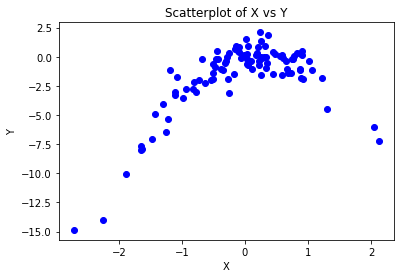

In [10]:
# Scatterplot of X vs Y
plt.scatter(x, y, c='blue')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot of X vs Y')
plt.show()


From the scatterplot, we see a nonlinear relationship between X and Y because the true model contains a quadratic term (-2x^2). The data resembles a quadratic shape.

c)

In [11]:
# Function to perform LOOCV
def loocv_error(X, y, degree):
    loo = LeaveOneOut()
    poly = PolynomialFeatures(degree=degree)
    errors = []
    
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Fit polynomial model
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        model = LinearRegression().fit(X_train_poly, y_train)
        
        # Predict and compute error
        y_pred = model.predict(X_test_poly)
        errors.append((y_pred - y_test) ** 2)
    
    # Return mean error
    return np.mean(errors)

X = x.reshape(-1, 1)

# Compute LOOCV errors for degrees 1, 2, 3, 4
degrees = [1, 2, 3, 4]
loocv_errors = [loocv_error(X, y, d) for d in degrees]

for d, error in zip(degrees, loocv_errors):
    print(f"Degree {d}: LOOCV Error = {round(error,3)}")


Degree 1: LOOCV Error = 6.633
Degree 2: LOOCV Error = 1.123
Degree 3: LOOCV Error = 1.302
Degree 4: LOOCV Error = 1.332


d)

In [12]:
rng = np.random.default_rng(2)
x_new = rng.normal(size=100)
y_new = x_new - 2 * x_new**2 + rng.normal(size=100)

X_new = x_new.reshape(-1, 1)

loocv_errors_new = [loocv_error(X_new, y_new, d) for d in degrees]

for d, error in zip(degrees, loocv_errors_new):
    print(f"Degree {d} (new seed): LOOCV Error = {error:.4f}")


Degree 1 (new seed): LOOCV Error = 7.5606
Degree 2 (new seed): LOOCV Error = 0.9840
Degree 3 (new seed): LOOCV Error = 0.9682
Degree 4 (new seed): LOOCV Error = 0.9660


The results differ because the data is generated with random noise each time, but the general trend remains similar.

e)

Model with a degree of 2 had the lowest error in part c). That was within my expectations considering the scatterplot in part b) which looks like it would fit best with a polynomial regression with degree 2.

f)

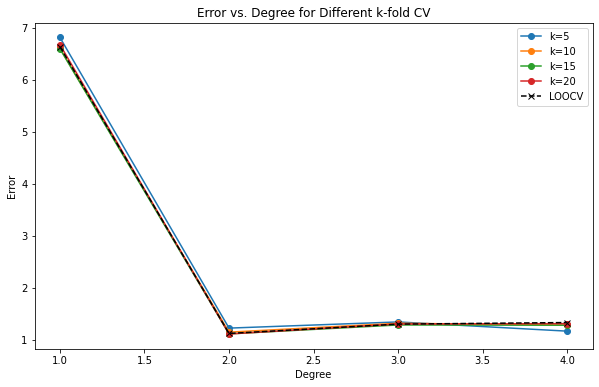

In [13]:
from sklearn.model_selection import KFold

def k_fold_cv_error(X, y, degree, k):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    poly = PolynomialFeatures(degree=degree)
    errors = []
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Fit polynomial model
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        model = LinearRegression().fit(X_train_poly, y_train)
        
        # Predict and compute error
        y_pred = model.predict(X_test_poly)
        errors.append(mean_squared_error(y_test, y_pred))
    
    # Return mean error
    return np.mean(errors)

k_values = [5, 10, 15, 20]
cv_errors = {k: [] for k in k_values}

# Compute errors for each k and degree
for k in k_values:
    for d in degrees:
        error = k_fold_cv_error(X, y, d, k)
        cv_errors[k].append(error)

# Plot the errors
plt.figure(figsize=(10, 6))
for k in k_values:
    plt.plot(degrees, cv_errors[k], marker='o', label=f'k={k}')
plt.plot(degrees, loocv_errors, marker='x', linestyle='--', label='LOOCV', color='black')

plt.xlabel('Degree')
plt.ylabel('Error')
plt.title('Error vs. Degree for Different k-fold CV')
plt.legend()
plt.show()
